
# Classification Mosquitoes Wingbeat using Capsule Network Mode

In [ ]:
# NEED ADD WAV AUDIO TO SPECTOGRAM

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import gc
import tensorflow as tf
from sklearn.model_selection import train_test_split
from scipy import ndimage
import nibabel as nib

In [4]:
import pandas as pd

In [5]:
import numpy as np                   # advanced math library
import matplotlib.pyplot as plt      # MATLAB like plotting routines
import random                        # for generating random numbers
from keras.models import Sequential  # Model type to be used
from keras.layers import Dense, Dropout, Activation  # Fixed this line
from keras.utils import to_categorical


In [6]:
# basic libraries 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# to store images 
from glob import glob

# to read images
import cv2

# for train-test split 
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# for modeling (all from tensorflow.keras)
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

# data augmentation and image processing
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.inception_v3 import preprocess_input, decode_predictions
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K

# tensorflow core
import tensorflow as tf
import tensorflow.experimental.numpy as tnp

# randomness
import random
from tqdm import tqdm

# garbage collector and image utils
import gc
from skimage import color
from skimage import io


In [7]:
import os
from glob import glob

# Define folder paths
path_aegypti = r'C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specaegypti'
path_albopictus = r'C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specalbopictus'
path_noise = r'C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specnoise'
path_others = r'C:\Users\USER\OneDrive\Desktop\SEM7\FYP\FYP\wingbeat new\spectogram4class\specothers'

# Image size (resize all images to this size)
image_size = [28, 28]

# Get image file paths
train_aegypti = glob(path_aegypti + '/*')
train_albopictus = glob(path_albopictus + '/*')
train_noise = glob(path_noise + '/*')
train_others = glob(path_others + '/*')

# Optional: Combine all into one list for later looping
all_train_data = [
    (train_aegypti, 0),        # class 0: aegypti
    (train_albopictus, 1),     # class 1: albopictus
    (train_noise, 2),          # class 2: noise
    (train_others, 3)          # class 3: others
]


In [8]:
print("No. of Aedes aegypti spectrograms    : ", len(train_aegypti))
print("No. of Aedes albopictus spectrograms : ", len(train_albopictus))
print("No. of Noise spectrograms            : ", len(train_noise))
print("No. of Other spectrograms            : ", len(train_others))

No. of Aedes aegypti spectrograms    :  486
No. of Aedes albopictus spectrograms :  400
No. of Noise spectrograms            :  242
No. of Other spectrograms            :  500


In [9]:
aegypti_data = []
aegypti_labels = []

albopictus_data = []
albopictus_labels = []

noise_data = []
noise_labels = []

others_data = []
others_labels = []

def Load_Images_Labels(files, label):
    data = []
    labels = []
    for i in range(len(files)):
        image = cv2.imread(files[i], cv2.IMREAD_COLOR)  # read image
        if image is not None:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # convert to grayscale
            image = cv2.resize(image, (28, 28))              # resize to 28x28
            data.append(image)
            labels.append(label)
    return data, labels

# Load all four classes
aegypti_data, aegypti_labels = Load_Images_Labels(train_aegypti, 0)
albopictus_data, albopictus_labels = Load_Images_Labels(train_albopictus, 1)
noise_data, noise_labels = Load_Images_Labels(train_noise, 2)
others_data, others_labels = Load_Images_Labels(train_others, 3)


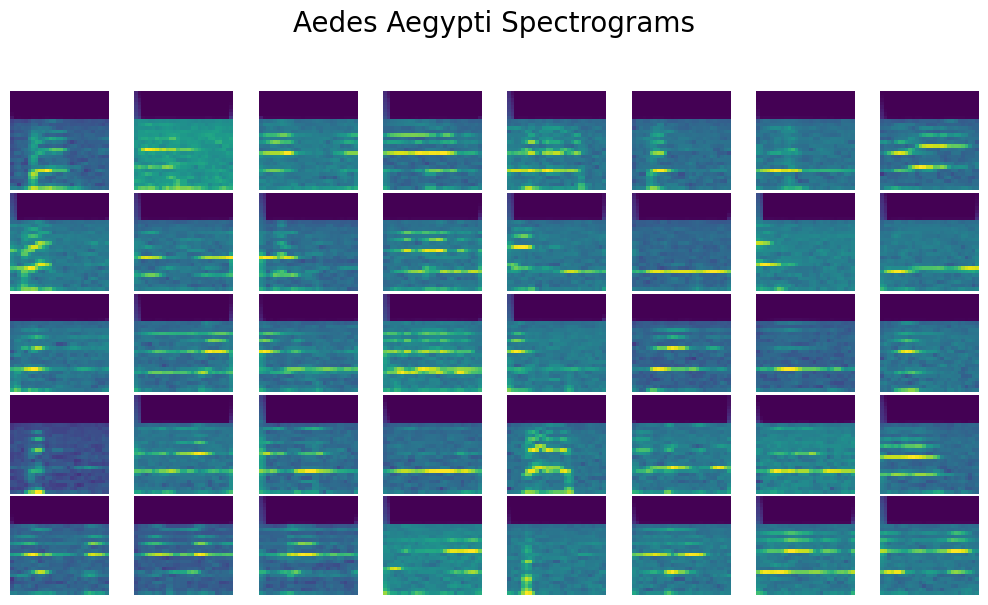

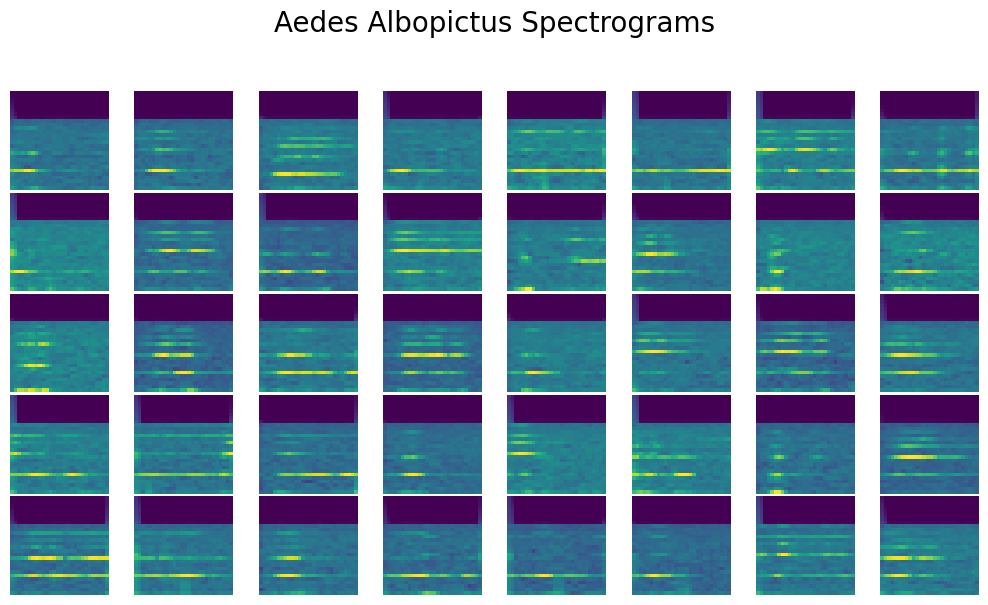

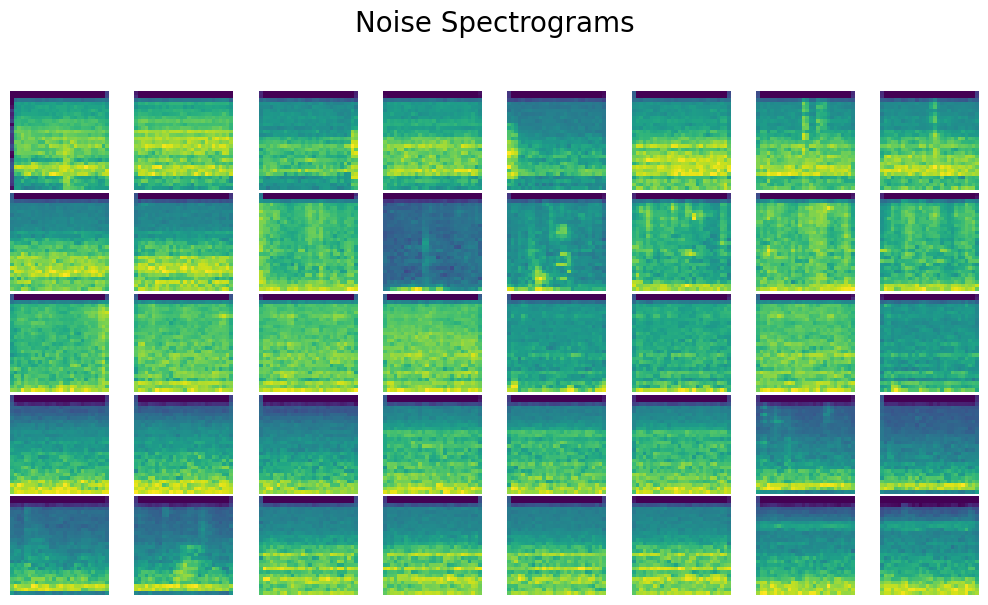

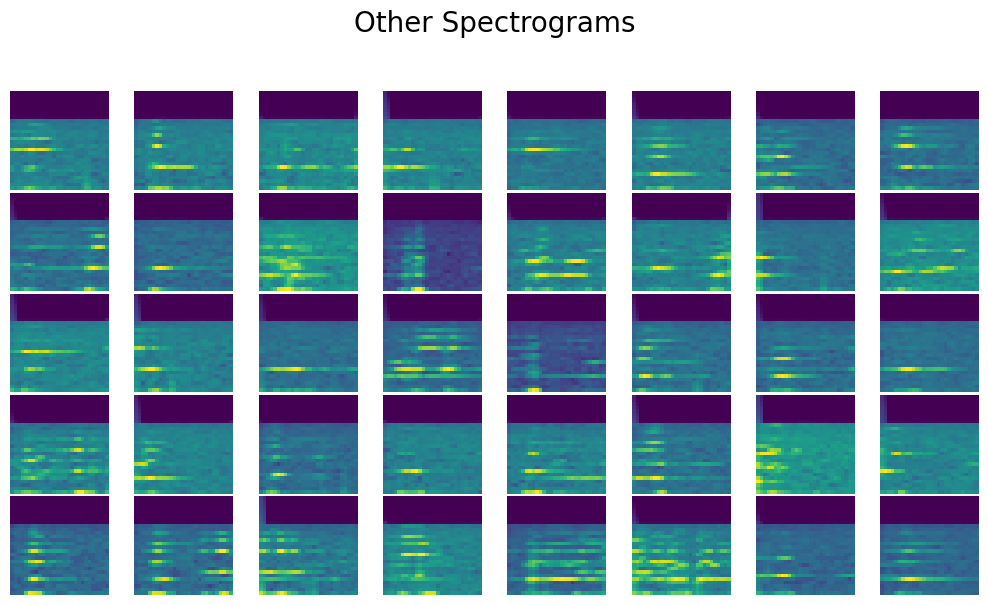

In [10]:
def Visualize_Spectrograms(images, title):
    nrows, ncols = 5, 8
    figsize = [10, 6]
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, facecolor=(1, 1, 1))
    
    for i, axi in enumerate(ax.flat):
        axi.imshow(images[i])         # Show each image in the grid
        axi.set_axis_off()            # Hide axis lines and labels

    plt.suptitle(title, fontsize=20)  # Add a main title
    plt.tight_layout(pad=0.2, rect=[0, 0, 1, 0.9])  # Adjust spacing
    plt.show()  

# Visualize some samples from each class

Visualize_Spectrograms(aegypti_data, 'Aedes Aegypti Spectrograms')
Visualize_Spectrograms(albopictus_data, 'Aedes Albopictus Spectrograms')
Visualize_Spectrograms(noise_data, 'Noise Spectrograms')
Visualize_Spectrograms(others_data, 'Other Spectrograms')



#Converting & Normalizing Image Data


aegypti_images = np.array(aegypti_data) / 255.0
albopictus_images = np.array(albopictus_data) / 255.0
noise_images = np.array(noise_data) / 255.0
others_images = np.array(others_data) / 255.0


In [11]:
# Splitting train and test for each class
Xa_train, Xa_test, ya_train, ya_test = train_test_split(aegypti_data, aegypti_labels, test_size=0.2, random_state=42)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(albopictus_data, albopictus_labels, test_size=0.2, random_state=42)
Xn_train, Xn_test, yn_train, yn_test = train_test_split(noise_data, noise_labels, test_size=0.2, random_state=42)
Xo_train, Xo_test, yo_train, yo_test = train_test_split(others_data, others_labels, test_size=0.2, random_state=42)

# Concatenating all data and labels
X_train = np.concatenate((Xa_train, Xb_train, Xn_train, Xo_train), axis=0)
X_test = np.concatenate((Xa_test, Xb_test, Xn_test, Xo_test), axis=0)

y_train = np.concatenate((ya_train, yb_train, yn_train, yo_train), axis=0)
y_test = np.concatenate((ya_test, yb_test, yn_test, yo_test), axis=0)

In [12]:
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from datetime import datetime


%load_ext tensorboard


In [13]:
# Shuffle the datasets (4 classes)
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)


In [14]:
# Print the shape of the data after splitting
print("Shape of Train Data:", X_train.shape)
print("Shape of Test Data:", X_test.shape)
print("Shape of Train Labels:", y_train.shape)
print("Shape of Test Labels:", y_test.shape)

Shape of Train Data: (1301, 28, 28)
Shape of Test Data: (327, 28, 28)
Shape of Train Labels: (1301,)
Shape of Test Labels: (327,)


In [15]:
# Parameters Based on Paper
epsilon = 1e-7
m_plus = 0.9
m_minus = 0.1
lambda_ = 0.5
alpha = 0.0005
epochs = 10
no_of_secondary_capsules = 10

optimizer = tf.keras.optimizers.Adam()

In [22]:
params = {
    "no_of_conv_kernels": 256,
    "no_of_primary_capsules": 32,
    "no_of_secondary_capsules": 10,
    "primary_capsule_vector": 8,
    "secondary_capsule_vector": 16,
    "r":3,
}

In [23]:
import numpy as np
from tqdm import tqdm
import tensorflow as tf
from datetime import datetime


%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [24]:
# Normalize the train data
X_train = X_train / 255.0
X_train = tf.cast(X_train, dtype=tf.float32)
# Since your images are color spectrograms (RGB), no need to add an extra dimension for grayscale.
X_train = tf.expand_dims(X_train, axis=-1)  # If you want a 4D tensor (batch_size, height, width, 1)

# Normalize the test data
X_test = X_test / 255.0
X_test = tf.cast(X_test, dtype=tf.float32)
X_test = tf.expand_dims(X_test, axis=-1)  # If needed, adjust this line as per the number of channels (3 or 1)

In [25]:

testing_dataset_size = X_test.shape[0]
training_dataset_size = X_train.shape[0]

In [26]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset = dataset.shuffle(buffer_size=len(dataset), reshuffle_each_iteration=True)
dataset = dataset.batch(batch_size=10)

In [27]:
testing = tf.data.Dataset.from_tensor_slices((X_test, y_test))
testing = testing.batch(batch_size=10)

# Capsule Network Method Definition

In [28]:
class CapsuleNetwork(tf.keras.Model):
    def __init__(self, no_of_conv_kernels, no_of_primary_capsules, primary_capsule_vector, no_of_secondary_capsules, secondary_capsule_vector, r):
        super(CapsuleNetwork, self).__init__()
        self.no_of_conv_kernels = no_of_conv_kernels
        self.no_of_primary_capsules = no_of_primary_capsules
        self.primary_capsule_vector = primary_capsule_vector
        self.no_of_secondary_capsules = no_of_secondary_capsules
        self.secondary_capsule_vector = secondary_capsule_vector
        self.r = r
        
        
        with tf.name_scope("Variables") as scope:
            self.convolution = tf.keras.layers.Conv2D(self.no_of_conv_kernels, [9,9], strides=[1,1], name='ConvolutionLayer', activation='relu')
            self.primary_capsule = tf.keras.layers.Conv2D(self.no_of_primary_capsules * self.primary_capsule_vector, [9,9], strides=[2,2], name="PrimaryCapsule")
            self.w = tf.Variable(tf.random_normal_initializer()(shape=[1, 1152, self.no_of_secondary_capsules, self.secondary_capsule_vector, self.primary_capsule_vector]), dtype=tf.float32, name="PoseEstimation", trainable=True)
            self.dense_1 = tf.keras.layers.Dense(units = 512, activation='relu')
            self.dense_2 = tf.keras.layers.Dense(units = 1024, activation='relu')
            self.dense_3 = tf.keras.layers.Dense(units = 784, activation='sigmoid', dtype='float32')
        
    def build(self, input_shape):
        pass
        
    def squash(self, s):
        with tf.name_scope("SquashFunction") as scope:
            s_norm = tf.norm(s, axis=-1, keepdims=True)
            return tf.square(s_norm)/(1 + tf.square(s_norm)) * s/(s_norm + epsilon)
    
    @tf.function
    def call(self, inputs):
        input_x, y = inputs
        # input_x.shape: (None, 28, 28, 1)
        # y.shape: (None, 10)
        
        x = self.convolution(input_x) # x.shape: (None, 20, 20, 256)
        x = self.primary_capsule(x) # x.shape: (None, 6, 6, 256)
        
        with tf.name_scope("CapsuleFormation") as scope:
            u = tf.reshape(x, (-1, self.no_of_primary_capsules * x.shape[1] * x.shape[2], 8)) # u.shape: (None, 1152, 8)
            u = tf.expand_dims(u, axis=-2) # u.shape: (None, 1152, 1, 8)
            u = tf.expand_dims(u, axis=-1) # u.shape: (None, 1152, 1, 8, 1)
            u_hat = tf.matmul(self.w, u) # u_hat.shape: (None, 1152, 10, 16, 1)
            u_hat = tf.squeeze(u_hat, [4]) # u_hat.shape: (None, 1152, 10, 16)

        
        with tf.name_scope("DynamicRouting") as scope:
            b = tf.zeros((input_x.shape[0], 1152, self.no_of_secondary_capsules, 1)) # b.shape: (None, 1152, 10, 1)
            for i in range(self.r): # self.r = 3
                c = tf.nn.softmax(b, axis=-2) # c.shape: (None, 1152, 10, 1)
                s = tf.reduce_sum(tf.multiply(c, u_hat), axis=1, keepdims=True) # s.shape: (None, 1, 10, 16)
                v = self.squash(s) # v.shape: (None, 1, 10, 16)
                agreement = tf.squeeze(tf.matmul(tf.expand_dims(u_hat, axis=-1), tf.expand_dims(v, axis=-1), transpose_a=True), [4]) # agreement.shape: (None, 1152, 10, 1)
                # Before matmul following intermediate shapes are present, they are not assigned to a variable but just for understanding the code.
                # u_hat.shape (Intermediate shape) : (None, 1152, 10, 16, 1)
                # v.shape (Intermediate shape): (None, 1, 10, 16, 1)
                # Since the first parameter of matmul is to be transposed its shape becomes:(None, 1152, 10, 1, 16)
                # Now matmul is performed in the last two dimensions, and others are broadcasted
                # Before squeezing we have an intermediate shape of (None, 1152, 10, 1, 1)
                b += agreement
                
        with tf.name_scope("Masking") as scope:
            y = tf.expand_dims(y, axis=-1) # y.shape: (None, 10, 1)
            y = tf.expand_dims(y, axis=1) # y.shape: (None, 1, 10, 1)
            mask = tf.cast(y, dtype=tf.float32) # mask.shape: (None, 1, 10, 1)
            v_masked = tf.multiply(mask, v) # v_masked.shape: (None, 1, 10, 16)
            
        with tf.name_scope("Reconstruction") as scope:
            v_ = tf.reshape(v_masked, [-1, self.no_of_secondary_capsules * self.secondary_capsule_vector]) # v_.shape: (None, 160)
            reconstructed_image = self.dense_1(v_) # reconstructed_image.shape: (None, 512)
            reconstructed_image = self.dense_2(reconstructed_image) # reconstructed_image.shape: (None, 1024)
            reconstructed_image = self.dense_3(reconstructed_image) # reconstructed_image.shape: (None, 784)
        
        return v, reconstructed_image

    @tf.function
    def predict_capsule_output(self, inputs):
        x = self.convolution(inputs) # x.shape: (None, 20, 20, 256)
        x = self.primary_capsule(x) # x.shape: (None, 6, 6, 256)
        
        with tf.name_scope("CapsuleFormation") as scope:
            u = tf.reshape(x, (-1, self.no_of_primary_capsules * x.shape[1] * x.shape[2], 8)) # u.shape: (None, 1152, 8)
            u = tf.expand_dims(u, axis=-2) # u.shape: (None, 1152, 1, 8)
            u = tf.expand_dims(u, axis=-1) # u.shape: (None, 1152, 1, 8, 1)
            u_hat = tf.matmul(self.w, u) # u_hat.shape: (None, 1152, 10, 16, 1)
            u_hat = tf.squeeze(u_hat, [4]) # u_hat.shape: (None, 1152, 10, 16)

        
        with tf.name_scope("DynamicRouting") as scope:
            b = tf.zeros((inputs.shape[0], 1152, self.no_of_secondary_capsules, 1)) # b.shape: (None, 1152, 10, 1)
            for i in range(self.r): # self.r = 3
                c = tf.nn.softmax(b, axis=-2) # c.shape: (None, 1152, 10, 1)
                s = tf.reduce_sum(tf.multiply(c, u_hat), axis=1, keepdims=True) # s.shape: (None, 1, 10, 16)
                v = self.squash(s) # v.shape: (None, 1, 10, 16)
                agreement = tf.squeeze(tf.matmul(tf.expand_dims(u_hat, axis=-1), tf.expand_dims(v, axis=-1), transpose_a=True), [4]) # agreement.shape: (None, 1152, 10, 1)
                # Before matmul following intermediate shapes are present, they are not assigned to a variable but just for understanding the code.
                # u_hat.shape (Intermediate shape) : (None, 1152, 10, 16, 1)
                # v.shape (Intermediate shape): (None, 1, 10, 16, 1)
                # Since the first parameter of matmul is to be transposed its shape becomes:(None, 1152, 10, 1, 16)
                # Now matmul is performed in the last two dimensions, and others are broadcasted
                # Before squeezing we have an intermediate shape of (None, 1152, 10, 1, 1)
                b += agreement
        return v

    @tf.function
    def regenerate_image(self, inputs):
        with tf.name_scope("Reconstruction") as scope:
            v_ = tf.reshape(inputs, [-1, self.no_of_secondary_capsules * self.secondary_capsule_vector]) # v_.shape: (None, 160)
            reconstructed_image = self.dense_1(v_) # reconstructed_image.shape: (None, 512)
            reconstructed_image = self.dense_2(reconstructed_image) # reconstructed_image.shape: (None, 1024)
            reconstructed_image = self.dense_3(reconstructed_image) # reconstructed_image.shape: (None, 784)
        return reconstructed_image




In [29]:
tf.summary.trace_on(graph=True, profiler=True)


In [31]:
model = CapsuleNetwork(**params)

# Loss Function

In [78]:
def loss_function(v, reconstructed_image, y, y_image):
    prediction = safe_norm(v)
    prediction = tf.reshape(prediction, [-1, no_of_secondary_capsules])
    
    left_margin = tf.square(tf.maximum(0.0, m_plus - prediction))
    right_margin = tf.square(tf.maximum(0.0, prediction - m_minus))
    
    l = tf.add(y * left_margin, lambda_ * (1.0 - y) * right_margin)
    
    margin_loss = tf.reduce_mean(tf.reduce_sum(l, axis=-1))
    
    y_image_flat = tf.reshape(y_image, [-1, 784])
    reconstruction_loss = tf.reduce_mean(tf.square(y_image_flat - reconstructed_image))
    
    loss = tf.add(margin_loss, alpha * reconstruction_loss)
    
    return loss

In [76]:
def safe_norm(v, axis=-1):
    v_ = tf.reduce_sum(tf.square(v), axis=axis, keepdims=True)
    return tf.sqrt(v_ + epsilon)

In [46]:
def train(x,y):
    y_one_hot = tf.one_hot(y, depth=10)
    with tf.GradientTape() as tape:
        v, reconstructed_image = model([x, y_one_hot])
        loss = loss_function(v, reconstructed_image, y_one_hot, x)
    grad = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grad, model.trainable_variables))
    return loss



In [53]:
def predict(model, x):
    pred = safe_norm(model.predict_capsule_output(x))
    pred = tf.squeeze(pred, [1])
    return np.argmax(pred, axis=1)[:, 0]

# Training Capsule Network Model

In [55]:
#Jadi(goodaccuracy)refer gemini
# Initialize lists to track training and validation accuracy and loss
training_accuracy = []
validation_accuracy = []
training_loss_history = []
validation_loss_history = []

# Epoch loop
for i in range(1, epochs + 1, 1):
    training_loss = 0.0
    validation_loss = 0.0
    with tqdm(total=len(dataset), desc=f"Epoch {i}/{epochs}", unit='batch') as pbar:
        # Training loop
        for X_batch, y_batch in dataset:
            loss = train(X_batch, y_batch)  # Assuming train function returns the loss
            training_loss += loss.numpy()
            pbar.set_postfix(Loss=f"{loss.numpy():.4f}")
            pbar.update(1)

    avg_training_loss = training_loss / len(dataset)
    training_loss_history.append(avg_training_loss)

    # Calculate training accuracy
    training_sum = 0
    for X_batch, y_batch in dataset:
        training_sum += sum(predict(model, X_batch) == y_batch.numpy())
    training_acc = training_sum / training_dataset_size
    training_accuracy.append(training_acc)

    # Validation loop
    val_sum = 0
    for X_batch_val, y_batch_val in testing:
        v_val, reconstructed_image_val = model([X_batch_val, tf.one_hot(y_batch_val, depth=no_of_secondary_capsules)])
        loss_val = loss_function(v_val, reconstructed_image_val, tf.one_hot(y_batch_val, depth=no_of_secondary_capsules), X_batch_val)
        validation_loss += loss_val.numpy()
        val_sum += sum(predict(model, X_batch_val) == y_batch_val.numpy())

    avg_validation_loss = validation_loss / len(testing)
    validation_loss_history.append(avg_validation_loss)
    val_acc = val_sum / testing_dataset_size
    validation_accuracy.append(val_acc)

    # Display loss, training and validation accuracy
    print_statement = f"Training Loss: {avg_training_loss:.4f} | Training Accuracy: {training_acc:.4f} | Validation Loss: {avg_validation_loss:.4f} | Validation Accuracy: {val_acc:.4f}"
    pbar.set_postfix_str(print_statement)
    print(print_statement)

# After training, you can print the final accuracy and loss
print("Final Training Accuracy:", training_accuracy[-1])
print("Final Validation Accuracy:", validation_accuracy[-1])
print("Final Training Loss:", training_loss_history[-1])
print("Final Validation Loss:", validation_loss_history[-1])

# Optionally, you can also plot the accuracy and loss over epochs if needed.

Epoch 1/10: 100%|██████████| 131/131 [02:07<00:00,  1.03batch/s, Loss=0.1893]


Training Loss: 0.2663 | Training Accuracy: 0.6580 | Validation Loss: 0.2359 | Validation Accuracy: 0.6055


Epoch 2/10: 100%|██████████| 131/131 [02:03<00:00,  1.06batch/s, Loss=0.4121]


Training Loss: 0.1947 | Training Accuracy: 0.7179 | Validation Loss: 0.1872 | Validation Accuracy: 0.6881


Epoch 3/10: 100%|██████████| 131/131 [02:03<00:00,  1.06batch/s, Loss=0.3036]


...

Training Loss: 0.1581 | Training Accuracy: 0.7786 | Validation Loss: 0.1739 | Validation Accuracy: 0.7339


Epoch 9/10: 100%|██████████| 131/131 [02:12<00:00,  1.01s/batch, Loss=0.4733]


Training Loss: 0.1576 | Training Accuracy: 0.7610 | Validation Loss: 0.1784 | Validation Accuracy: 0.7645


Epoch 10/10: 100%|██████████| 131/131 [02:44<00:00,  1.26s/batch, Loss=0.0939]


Training Loss: 0.1574 | Training Accuracy: 0.7733 | Validation Loss: 0.1776 | Validation Accuracy: 0.7523
Final Training Accuracy: 0.7732513451191392
Final Validation Accuracy: 0.7522935779816514
Final Training Loss: 0.15737877561504604
Final Validation Loss: 0.17760571645516338


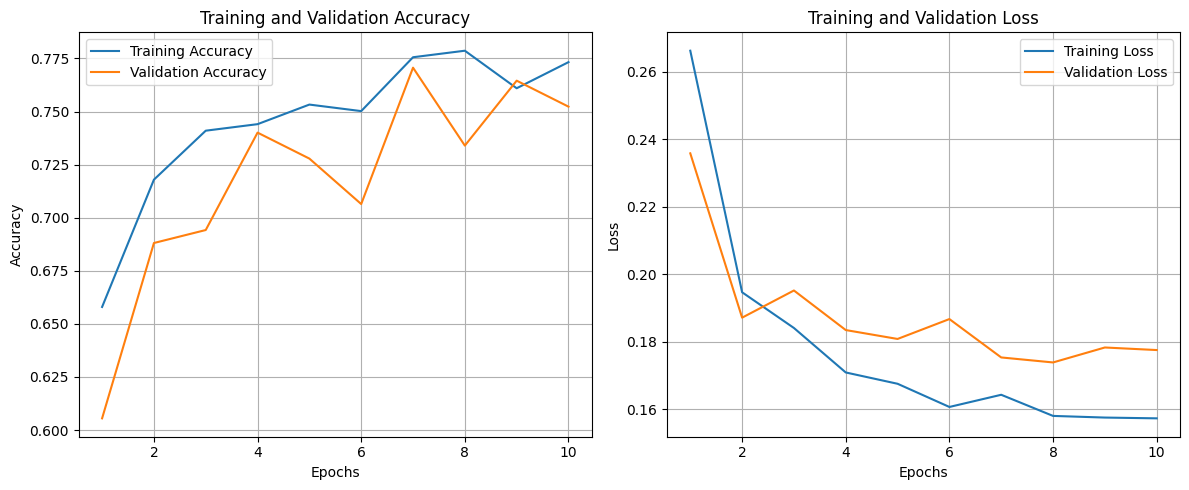

In [61]:
# Plotting training and validation curves together
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), training_accuracy, label='Training Accuracy')
plt.plot(range(1, epochs + 1), validation_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), training_loss_history, label='Training Loss')
plt.plot(range(1, epochs + 1), validation_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Model Evaluation

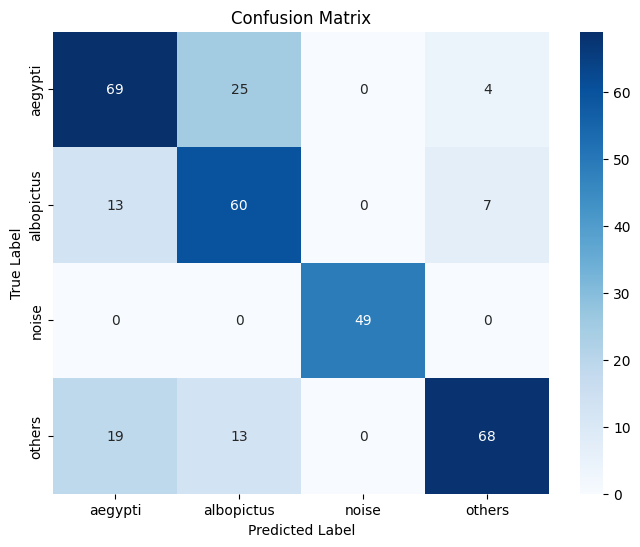


Classification Report:
              precision    recall  f1-score   support

     aegypti       0.68      0.70      0.69        98
  albopictus       0.61      0.75      0.67        80
       noise       1.00      1.00      1.00        49
      others       0.86      0.68      0.76       100

    accuracy                           0.75       327
   macro avg       0.79      0.78      0.78       327
weighted avg       0.77      0.75      0.75       327



In [63]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# After training, evaluate on the test set and generate confusion matrix
test_predictions = []
test_true_labels = []

for X_batch_test, y_batch_test in testing:
    predictions = predict(model, X_batch_test)
    test_predictions.extend(predictions)
    test_true_labels.extend(y_batch_test.numpy())

cm = confusion_matrix(test_true_labels, test_predictions)

# Get class labels (assuming you have 4 classes: 0, 1, 2, 3)
class_labels = ['aegypti', 'albopictus', 'noise', 'others']  # Replace with your actual class names

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report for more detailed metrics
print("\nClassification Report:")
print(classification_report(test_true_labels, test_predictions, target_names=class_labels))

In [65]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Assuming you have already calculated the confusion matrix 'cm'
# and have your 'class_labels' defined

num_classes = cm.shape[0]
per_class_metrics = {}

for i in range(num_classes):
    # True Positives
    tp = cm[i, i]
    # False Positives
    fp = np.sum(cm[:, i]) - tp
    # False Negatives
    fn = np.sum(cm[i, :]) - tp
    # True Negatives
    tn = np.sum(cm) - tp - fp - fn

    # Sensitivity (Recall)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    # Specificity
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    # Accuracy
    accuracy = (tp + tn) / np.sum(cm) if np.sum(cm) > 0 else 0.0

    per_class_metrics[class_labels[i]] = {
        'Sensitivity': f'{sensitivity:.2f}',
        'Specificity': f'{specificity:.2f}',
        'Accuracy': f'{accuracy:.2f}'
    }

# Print the per-class metrics
for class_name, metrics in per_class_metrics.items():
    print(f"Class {class_name}:")
    print(f"  Sensitivity: {metrics['Sensitivity']}")
    print(f"  Specificity: {metrics['Specificity']}")
    print(f"  Accuracy: {metrics['Accuracy']}")
    print()

Class aegypti:
  Sensitivity: 0.70
  Specificity: 0.86
  Accuracy: 0.81

Class albopictus:
  Sensitivity: 0.75
  Specificity: 0.85
  Accuracy: 0.82

Class noise:
  Sensitivity: 1.00
  Specificity: 1.00
  Accuracy: 1.00

Class others:
  Sensitivity: 0.68
  Specificity: 0.95
  Accuracy: 0.87



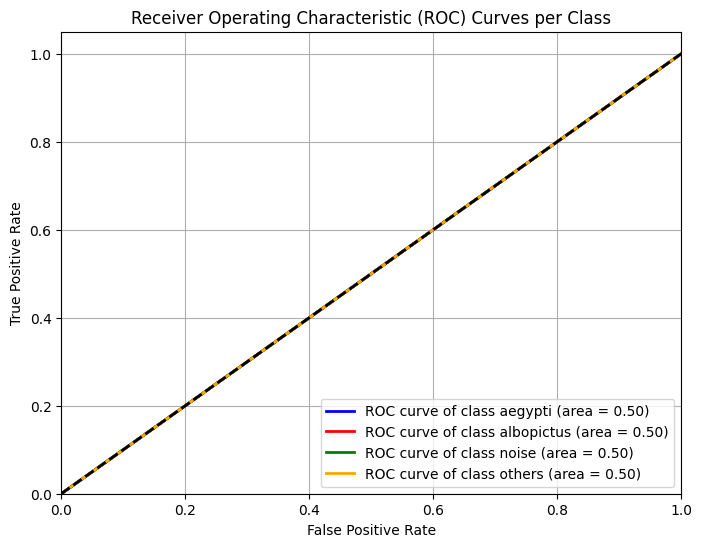

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import tensorflow as tf

# Assuming you have:
# 1. Your trained 'model' (an instance of your CapsuleNetwork class)
# 2. Your test data 'X_test' (NumPy array or TensorFlow tensor)
# 3. Your test labels 'test_true_labels' (NumPy array of integers)
# 4. Your 'class_labels' (a list of strings representing your class names)
# 5. Your 'safe_norm' function defined as in your earlier code

@tf.function
def predict_proba(model, inputs):
    v = model.predict_capsule_output(inputs)
    magnitudes = safe_norm(v)
    magnitudes_squeezed = tf.squeeze(magnitudes, axis=[1]) # Remove the extra dimension
    probabilities = tf.nn.softmax(magnitudes_squeezed, axis=-1)
    return probabilities

# Get the probability scores for each class from your model
y_score = predict_proba(model, X_test)

if y_score is not None:
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    n_classes = len(class_labels)
    binarized_y_test = label_binarize(test_true_labels, classes=np.arange(n_classes))

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(binarized_y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves for each class
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'red', 'green', 'orange']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve of class {class_labels[i]} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves per Class')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
else:
    print("ROC curve generation skipped due to the absence of 'predict_proba'.")

# Model Saved

In [86]:
import tensorflow as tf

# Assuming 'model' is your trained CapsuleNetwork instance

# Define the path where you want to save the model
save_path = './saved_capsule_network_model.h5'  # You can change this path

try:
    # Save the entire model (architecture and weights)
    model.save(save_path)
    print(f"Capsule Network model saved successfully at: {save_path}")
except Exception as e:
    print(f"Error saving the model: {e}")

# --- Optional: How to load the saved model later ---
# To load the model later:
# loaded_model = tf.keras.models.load_model(save_path)
# print("Capsule Network model loaded successfully.")
# # You can now use 'loaded_model' for predictions:
# # predictions = loaded_model.predict(new_data)

Capsule Network model saved successfully at: ./saved_capsule_network_model.h5
